<h2 align="center">Лабораторна робота № 5<br>Варіант 7</h2>

In [5]:
import numpy as np
import pandas as pd
import math
from scipy.interpolate import CubicSpline
from scipy.misc import derivative
import matplotlib.pyplot as plt

In [6]:
class InterpolationSolver:
    def __init__(self, func, a, b, n_nodes):
        self.func = func
        self.a = a
        self.b = b
        self.n_nodes = n_nodes
        # Формуємо рівновіддалені вузли
        self.x_nodes = np.linspace(a, b, n_nodes)
        self.y_nodes = self.func(self.x_nodes)
        self.h = self.x_nodes[1] - self.x_nodes[0]
        
        # Обчислення розділених різниць для Ньютона
        self.div_diff = self._compute_divided_differences()
        # Побудова кубічного сплайна
        self.spline = CubicSpline(self.x_nodes, self.y_nodes, bc_type='natural')
        
    def _compute_divided_differences(self):
        """Обчислення таблиці розділених різниць для полінома Ньютона."""
        n = self.n_nodes
        table = np.zeros((n, n))
        table[:, 0] = self.y_nodes
        for j in range(1, n):
            for i in range(n - j):
                table[i][j] = (table[i + 1][j - 1] - table[i][j - 1]) / (self.x_nodes[i + j] - self.x_nodes[i])
        return table[0, :]
        
    def newton_poly(self, x):
        """Обчислення значення полінома Ньютона у точці x."""
        n = self.n_nodes
        result = self.div_diff[0]
        product = 1.0
        for i in range(1, n):
            product *= (x - self.x_nodes[i - 1])
            result += self.div_diff[i] * product
        return result

    def analyze_errors(self):
        """Аналіз практичної та теоретичної похибок на щільній сітці."""
        x_dense = np.linspace(self.a, self.b, 500)
        y_true = self.func(x_dense)
        y_newton = np.array([self.newton_poly(x) for x in x_dense])
        y_spline = self.spline(x_dense)
        
        # Практична похибка (максимальне відхилення)
        max_err_newton = np.max(np.abs(y_true - y_newton))
        max_err_spline = np.max(np.abs(y_true - y_spline))
        
        print(f"=== Практична максимальна похибка ===")
        print(f"Поліном Ньютона: {max_err_newton:.2e}")
        print(f"Кубічний сплайн: {max_err_spline:.2e}\n")

    def print_nodes_table(self):
        """Виведення таблиці значень у вузлах інтерполяції."""
        print("=== Таблиця вузлів інтерполяції ===")
        df = pd.DataFrame({
            'x_i': np.round(self.x_nodes, 6),
            'f(x_i)': np.round(self.y_nodes, 6)
        })
        print(df.to_string(index=False))

In [7]:
f = lambda x: 1 / np.cos(x)

solver = InterpolationSolver(func=f, a=0.0, b=np.pi/3, n_nodes=15)
solver.print_nodes_table()
print("\n")
solver.analyze_errors()

=== Таблиця вузлів інтерполяції ===
     x_i   f(x_i)
0.000000 1.000000
0.074800 1.002804
0.149600 1.011295
0.224399 1.025717
0.299199 1.046493
0.373999 1.074260
0.448799 1.109916
0.523599 1.154701
0.598399 1.210304
0.673198 1.279048
0.747998 1.364160
0.822798 1.470215
0.897598 1.603875
0.972398 1.775190
1.047198 2.000000


=== Практична максимальна похибка ===
Поліном Ньютона: 2.37e-07
Кубічний сплайн: 3.74e-03



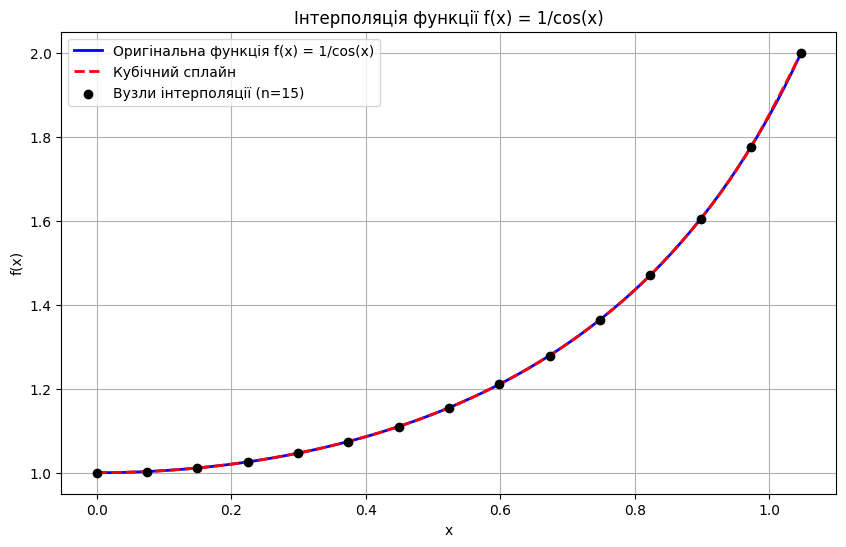

In [8]:
x_dense = np.linspace(0, np.pi/3, 200)
y_true = f(x_dense)
y_spline = solver.spline(x_dense)

plt.figure(figsize=(10, 6))
plt.plot(x_dense, y_true, 'b-', label='Оригінальна функція f(x) = 1/cos(x)', linewidth=2)
plt.plot(x_dense, y_spline, 'r--', label='Кубічний сплайн', linewidth=2)
plt.scatter(solver.x_nodes, solver.y_nodes, color='black', zorder=5, label='Вузли інтерполяції (n=15)')

plt.title('Інтерполяція функції f(x) = 1/cos(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.savefig('plot.png', dpi=300)
plt.show()